# Projekt 01 (basic) — Suchalgorithmen: A\*, UCS, BFS, IDDFS

**Modul 06 — Theorie der KI 1**

In diesem Notebook implementierst und *vergleichst* du die klassischen
Suchverfahren aus Teil 1 & 2 des Skripts an zwei konkreten Problemen:
der **Rumaenien-Karte** (Wegplanung mit echten km-Kosten) und dem
**8-Puzzle**.

Ziel ist nicht nur, dass die Algorithmen laufen, sondern dass du die
*Theorie empirisch nachpruefst*:
- UCS und A\* sind **optimal**, BFS und Greedy im Allgemeinen **nicht**.
- Eine **hoehere zulaessige Heuristik** (Manhattan $h_2$ statt Hamming $h_1$)
  expandiert **weniger Knoten** — die *Dominanz* aus dem Skript, sichtbar gemacht.

> **So arbeitest du:** Fuehre die vorgegebenen Zellen (Infrastruktur,
> BFS, Best-First) der Reihe nach aus. Loese dann **Aufgabe 1–3**
> (die Zellen mit `TODO` / `NotImplementedError`). Die Musterloesung
> liegt im Ordner `loesung/`.

## Setup

Dieses Projekt braucht nur die Standardbibliothek und `matplotlib`
(fuer ein Balkendiagramm). Beides ist im Repo-`venv` bereits installiert
(siehe `SETUP.md` und `requirements.txt` im Wurzelverzeichnis).

Waehle in Jupyter/VS Code den Kernel des `.venv`. Dann einfach die Zellen
von oben nach unten ausfuehren.

In [1]:
# Nur Standardbibliothek + matplotlib (fuer einen Vergleichs-Balken am Ende).
import heapq
import itertools
from collections import deque
from dataclasses import dataclass, field
from typing import Optional, Any, Callable
import matplotlib.pyplot as plt

print("Bibliotheken geladen.")

Bibliotheken geladen.


## Teil A — Infrastruktur (vorgegeben)

Zuerst die Bausteine, die *alle* Suchverfahren teilen: der **Knoten**
(ein Pfad im Suchbaum), die Funktion **`expand`** (erzeugt Kinder gemaess
Uebergangsmodell) und die abstrakte **`Problem`**-Schnittstelle. Danach die
zwei konkreten Probleme. Lies den Code — du brauchst ihn fuer die Aufgaben.

In [2]:
# ---- Knoten des Suchbaums -------------------------------------------------
@dataclass
class Node:
    """Ein Knoten IST ein Pfad: er kennt seinen Zustand, seinen Elter,
    die Aktion die hierher fuehrte, die Pfadkosten g und die Tiefe."""
    state: Any
    parent: "Optional[Node]" = None
    action: Any = None
    path_cost: float = 0.0      # g(n)
    depth: int = 0

def path_actions(node: Node):
    """Rekonstruiert die Aktionsfolge von der Wurzel bis node."""
    actions = []
    while node.parent is not None:
        actions.append(node.action)
        node = node.parent
    return list(reversed(actions))

def path_states(node: Node):
    """Zustandsfolge von der Wurzel bis node (fuer Zyklencheck)."""
    states = []
    while node is not None:
        states.append(node.state)
        node = node.parent
    return list(reversed(states))

def expand(problem, node: Node):
    """Erzeugt alle Kindknoten von node gemaess Uebergangsmodell."""
    s = node.state
    for action in problem.actions(s):
        s2 = problem.result(s, action)
        cost = node.path_cost + problem.action_cost(s, action, s2)
        yield Node(s2, node, action, cost, node.depth + 1)

print("Suchbaum-Infrastruktur bereit.")

Suchbaum-Infrastruktur bereit.


In [3]:
# ---- Abstrakte Problemschnittstelle ---------------------------------------
class Problem:
    """Ein Suchproblem (S, s0, A, Result, Goal, c). Konkrete Probleme
    erben und ueberschreiben die Methoden."""
    def __init__(self, initial, goal=None):
        self.initial = initial
        self.goal = goal
    def actions(self, state):        raise NotImplementedError
    def result(self, state, action): raise NotImplementedError
    def is_goal(self, state):        return state == self.goal
    def action_cost(self, s, a, s2): return 1          # Default: Einheitskosten
    def h(self, state):              return 0          # Default-Heuristik (uninformiert)

print("Problem-Basisklasse bereit.")

Problem-Basisklasse bereit.


In [4]:
# ---- Konkretes Problem 1: Rumaenien-Karte ---------------------------------
# Ungerichteter Graph: Stadt -> {Nachbar: Strassenlaenge in km}
romania_map = {
    "Arad": {"Zerind": 75, "Sibiu": 140, "Timisoara": 118},
    "Zerind": {"Arad": 75, "Oradea": 71},
    "Oradea": {"Zerind": 71, "Sibiu": 151},
    "Sibiu": {"Arad": 140, "Oradea": 151, "Fagaras": 99, "Rimnicu": 80},
    "Timisoara": {"Arad": 118, "Lugoj": 111},
    "Lugoj": {"Timisoara": 111, "Mehadia": 70},
    "Mehadia": {"Lugoj": 70, "Drobeta": 75},
    "Drobeta": {"Mehadia": 75, "Craiova": 120},
    "Craiova": {"Drobeta": 120, "Rimnicu": 146, "Pitesti": 138},
    "Rimnicu": {"Sibiu": 80, "Craiova": 146, "Pitesti": 97},
    "Fagaras": {"Sibiu": 99, "Bucharest": 211},
    "Pitesti": {"Rimnicu": 97, "Craiova": 138, "Bucharest": 101},
    "Bucharest": {"Fagaras": 211, "Pitesti": 101, "Giurgiu": 90, "Urziceni": 85},
    "Giurgiu": {"Bucharest": 90},
    "Urziceni": {"Bucharest": 85, "Hirsova": 98, "Vaslui": 142},
    "Hirsova": {"Urziceni": 98, "Eforie": 86},
    "Eforie": {"Hirsova": 86},
    "Vaslui": {"Urziceni": 142, "Iasi": 92},
    "Iasi": {"Vaslui": 92, "Neamt": 87},
    "Neamt": {"Iasi": 87},
}
# Luftlinien-Distanz zu Bukarest (zulaessige, konsistente Heuristik).
sld_to_bucharest = {
    "Arad": 366, "Bucharest": 0, "Craiova": 160, "Drobeta": 242, "Eforie": 161,
    "Fagaras": 176, "Giurgiu": 77, "Hirsova": 151, "Iasi": 226, "Lugoj": 244,
    "Mehadia": 241, "Neamt": 234, "Oradea": 380, "Pitesti": 100, "Rimnicu": 193,
    "Sibiu": 253, "Timisoara": 329, "Urziceni": 80, "Vaslui": 199, "Zerind": 374,
}

class RomaniaProblem(Problem):
    def actions(self, state):        return list(romania_map[state].keys())
    def result(self, state, action): return action          # Aktion = Zielstadt
    def action_cost(self, s, a, s2): return romania_map[s][s2]
    def h(self, state):              return sld_to_bucharest[state]

romania = RomaniaProblem("Arad", "Bucharest")
print("Rumaenien-Problem bereit. Aktionen von Arad:", romania.actions("Arad"))

Rumaenien-Problem bereit. Aktionen von Arad: ['Zerind', 'Sibiu', 'Timisoara']


In [5]:
# ---- Konkretes Problem 2: 8-Puzzle ----------------------------------------
# Zustand = Tupel der 9 Felder, 0 = Luecke. Ziel: (1,2,3,4,5,6,7,8,0)
GOAL8 = (1, 2, 3, 4, 5, 6, 7, 8, 0)

class EightPuzzle(Problem):
    def __init__(self, initial, goal=GOAL8):
        super().__init__(initial, goal)
    def actions(self, state):
        i = state.index(0)          # Position der Luecke (0..8)
        r, c = divmod(i, 3)
        acts = []
        if r > 0: acts.append("U")
        if r < 2: acts.append("D")
        if c > 0: acts.append("L")
        if c < 2: acts.append("R")
        return acts
    def result(self, state, action):
        i = state.index(0)
        swap = {"U": i - 3, "D": i + 3, "L": i - 1, "R": i + 1}[action]
        lst = list(state)
        lst[i], lst[swap] = lst[swap], lst[i]
        return tuple(lst)
    def action_cost(self, s, a, s2): return 1
    # --- zwei zulaessige Heuristiken ---
    def h1(self, state):            # fehlplatzierte Kacheln (Hamming), ohne Luecke
        return sum(1 for i, v in enumerate(state) if v != 0 and v != self.goal[i])
    def h2(self, state):            # Summe der Manhattan-Distanzen
        total = 0
        for i, v in enumerate(state):
            if v == 0:
                continue
            gi = self.goal.index(v)
            total += abs(i // 3 - gi // 3) + abs(i % 3 - gi % 3)
        return total
    h = h2                          # Default: die staerkere Heuristik

def show8(state):
    return "\n".join(" ".join(str(x) if x else "_" for x in state[r*3:r*3+3]) for r in range(3))

# Eine um 15 Zuege verschobene, loesbare Startstellung (zeigt die Dominanz klar).
start8 = (2, 6, 3, 1, 8, 4, 7, 0, 5)
p8 = EightPuzzle(start8)
print("8-Puzzle Start:\n" + show8(start8))
print("h1 =", p8.h1(start8), " h2 =", p8.h2(start8))

8-Puzzle Start:
2 6 3
1 8 4
7 _ 5
h1 = 6  h2 = 9


## Teil B — BFS als Vorbild (vorgegeben)

Breitensuche ist vollstaendig vorgegeben, damit du das Muster siehst:
FIFO-Frontier, `reached`-Menge gegen Zyklen, Zieltest beim Erzeugen.
**Beachte:** BFS minimiert die *Zahl der Schritte*, nicht die *km* — auf
der Karte mit ungleichen Kosten ist BFS daher **nicht** garantiert optimal.

In [6]:
# ---- Breitensuche (BFS) — vollstaendig als Vorbild vorgegeben --------------
def breadth_first_search(problem):
    """Graph-BFS. Zieltest beim ERZEUGEN (spart eine Schicht). FIFO-Queue.
    Rueckgabe: (Zielknoten oder None, Anzahl expandierter Knoten)."""
    node = Node(problem.initial)
    if problem.is_goal(node.state):
        return node, 0
    frontier = deque([node])           # FIFO
    reached = {problem.initial}
    expanded = 0
    while frontier:
        node = frontier.popleft()
        expanded += 1
        for child in expand(problem, node):
            s = child.state
            if problem.is_goal(s):
                return child, expanded
            if s not in reached:
                reached.add(s)
                frontier.append(child)
    return None, expanded

goal, exp = breadth_first_search(romania)
print("BFS Arad->Bucharest:", path_states(goal))
print("Pfadkosten:", goal.path_cost, "| expandierte Knoten:", exp)
print("(BFS minimiert die ZAHL der Schritte, nicht die km — daher evtl. nicht optimal!)")

BFS Arad->Bucharest: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
Pfadkosten: 450.0 | expandierte Knoten: 6
(BFS minimiert die ZAHL der Schritte, nicht die km — daher evtl. nicht optimal!)


## Teil C — Generische Bestensuche (vorgegeben)

Die entscheidende Einsicht des Skripts: **UCS, A\* und Greedy unterscheiden
sich nur in einer Zeile** — der Bewertungsfunktion $f(n)$. `best_first_search`
implementiert das Gemeinsame (Prioritaets-Frontier nach $f$, Zieltest beim
Expandieren, billigeren Pfad ersetzen). Die einzelnen Verfahren baust du
gleich, indem du das richtige $f$ einsetzt.

In [7]:
# ---- Generische Bestensuche (Best-First) — vorgegeben ---------------------
def best_first_search(problem, f: Callable[[Node], float]):
    """Expandiert immer den Frontier-Knoten mit kleinstem f(n).
    Zieltest beim EXPANDIEREN. Ersetzt einen Frontier-Zustand, wenn ein
    billigerer Pfad gefunden wird. Rueckgabe: (Zielknoten oder None, #expandiert)."""
    node = Node(problem.initial)
    counter = itertools.count()        # eindeutiger Tie-Breaker fuer den Heap
    frontier = [(f(node), next(counter), node)]
    reached = {problem.initial: node}
    expanded = 0
    while frontier:
        _, _, node = heapq.heappop(frontier)
        if problem.is_goal(node.state):
            return node, expanded
        expanded += 1
        for child in expand(problem, node):
            s = child.state
            if s not in reached or child.path_cost < reached[s].path_cost:
                reached[s] = child
                heapq.heappush(frontier, (f(child), next(counter), child))
    return None, expanded

print("best_first_search bereit — UCS und A* sind nur die richtige Wahl von f.")

best_first_search bereit — UCS und A* sind nur die richtige Wahl von f.


### Aufgabe 1 — UCS und A\* (das richtige $f$ waehlen)

- **UCS:** $f(n) = g(n)$ — nur die bisherigen Pfadkosten.
- **A\*:** $f(n) = g(n) + h(n)$ — Kosten plus geschaetzte Restkosten.
- **Greedy:** $f(n) = h(n)$ — nur die Heuristik (zum Vergleich).

Fuelle die drei Funktionen unten. Wenn korrekt, liefern UCS und A\* beide
**418 km** fuer Arad → Bukarest, aber A\* expandiert **weniger** Knoten.

In [8]:
# ---- UCS und A* als Spezialfaelle von best_first_search -------------------
def uniform_cost_search(problem):
    # UCS: f(n) = g(n) = bisherige Pfadkosten
    return best_first_search(problem, f=lambda n: n.path_cost)

def astar_search(problem, h=None):
    # A*: f(n) = g(n) + h(n)
    h = h or problem.h
    return best_first_search(problem, f=lambda n: n.path_cost + h(n.state))

def greedy_search(problem, h=None):
    # Greedy Best-First: f(n) = h(n)  (ignoriert g -> nicht optimal!)
    h = h or problem.h
    return best_first_search(problem, f=lambda n: h(n.state))

for name, fn in [("UCS", uniform_cost_search), ("A* (SLD)", astar_search)]:
    goal, exp = fn(romania)
    print(f"{name:10s} Arad->Bucharest: kosten={goal.path_cost:4.0f} km | "
          f"expandiert={exp:2d} | pfad={path_states(goal)}")

UCS        Arad->Bucharest: kosten= 418 km | expandiert=12 | pfad=['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest']
A* (SLD)   Arad->Bucharest: kosten= 418 km | expandiert= 5 | pfad=['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest']


### Aufgabe 2 — IDDFS

Iterative Vertiefung kombiniert den kleinen Speicher der Tiefensuche mit
der Vollstaendigkeit der Breitensuche. Implementiere die rekursive
**tiefenbeschraenkte Suche** und die aeussere Schleife, die das Tiefenlimit
schrittweise erhoeht. Achte auf den **Zyklencheck** entlang des aktuellen
Pfades (sonst laeuft DFS im Kreis).

In [9]:
# ---- Iterative Tiefensuche (IDDFS) ----------------------------------------
def depth_limited_search(problem, limit):
    """Rekursive DFS bis Tiefe limit. Rueckgabe: (Ergebnis, #expandiert).
    Ergebnis ist ein Node, der String 'cutoff' oder None (kein Ziel)."""
    expanded = [0]
    def recurse(node):
        if problem.is_goal(node.state):
            return node
        if node.depth == limit:
            return "cutoff"
        expanded[0] += 1
        cutoff = False
        seen_on_path = set(path_states(node))          # Zyklencheck
        for child in expand(problem, node):
            if child.state in seen_on_path:
                continue
            res = recurse(child)
            if res == "cutoff":
                cutoff = True
            elif res is not None:
                return res
        return "cutoff" if cutoff else None
    result = recurse(Node(problem.initial))
    return result, expanded[0]

def iterative_deepening_search(problem, max_depth=60):
    total = 0
    for limit in range(max_depth + 1):
        result, exp = depth_limited_search(problem, limit)
        total += exp
        if result != "cutoff":
            return result, total, limit
    return None, total, None

goal, exp, lim = iterative_deepening_search(romania)
print("IDDFS Arad->Bucharest:", path_states(goal),
      "| Loesungstiefe:", lim, "| expandiert (kumuliert):", exp)

IDDFS Arad->Bucharest: ['Arad', 'Sibiu', 'Fagaras', 'Bucharest'] | Loesungstiefe: 3 | expandiert (kumuliert): 11


### Aufgabe 3 — Heuristik-Dominanz sichtbar machen

Jetzt der Kern der informierten Suche: Loese *dasselbe* 8-Puzzle mit UCS,
A\*($h_1$, Hamming) und A\*($h_2$, Manhattan) und zaehle die expandierten
Knoten. Du solltest sehen: **alle finden dieselbe optimale Laenge**, aber
$h_2 \le h_1 \le$ UCS bei der Knotenzahl — die *Dominanz* aus dem Skript.

Optimale Loesungslaenge: 15 Zuege

UCS         :  5257 expandierte Knoten, Laenge 15
A* mit h1   :   457 expandierte Knoten, Laenge 15
A* mit h2   :   147 expandierte Knoten, Laenge 15


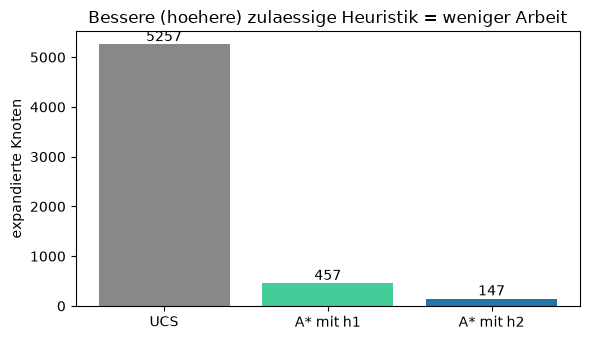

In [10]:
# ---- Experiment: Heuristik-Dominanz auf dem 8-Puzzle ----------------------
# Wir loesen dasselbe 8-Puzzle mit UCS, A*(h1) und A*(h2) und zaehlen,
# wie viele Knoten jedes Verfahren expandiert. Erwartung (Dominanz):
#   UCS  >=  A*(h1)  >=  A*(h2)      und alle finden dieselbe optimale Laenge.
results = {}
solved = astar_search(p8, h=p8.h2)[0]
opt_len = solved.path_cost
print(f"Optimale Loesungslaenge: {opt_len:.0f} Zuege\n")

for name, algo in [
    ("UCS",        lambda: uniform_cost_search(p8)),
    ("A* mit h1",  lambda: astar_search(p8, h=p8.h1)),
    ("A* mit h2",  lambda: astar_search(p8, h=p8.h2)),
]:
    node, exp = algo()
    results[name] = exp
    assert node.path_cost == opt_len, "alle sollten optimal sein!"
    print(f"{name:12s}: {exp:5d} expandierte Knoten, Laenge {node.path_cost:.0f}")

plt.figure(figsize=(6, 3.5))
plt.bar(results.keys(), results.values(), color=["#888", "#4C9", "#27A"])
plt.ylabel("expandierte Knoten")
plt.title("Bessere (hoehere) zulaessige Heuristik = weniger Arbeit")
for i, v in enumerate(results.values()):
    plt.text(i, v, str(v), ha="center", va="bottom")
plt.tight_layout(); plt.show()

## Teil D — Abschluss-Check: Optimalitaet

Zum Schluss der Beweis am Beispiel: Greedy und BFS finden einen Weg, aber
nicht den *billigsten*; UCS und A\* schon (418 km). Fuehre die Zelle aus —
der `assert` bestaetigt es.

In [11]:
# ---- Selbstcheck: greedy ist NICHT optimal, A* schon --------------------
g_node, _ = greedy_search(romania)
a_node, _ = astar_search(romania)
print("Greedy-Kosten:", g_node.path_cost, "->", path_states(g_node))
print("A*-Kosten    :", a_node.path_cost, "->", path_states(a_node))
print()
print("Alle vier Verfahren im Vergleich (Arad->Bucharest):")
for name, fn in [("BFS", breadth_first_search),
                 ("UCS", uniform_cost_search),
                 ("A*",  astar_search),
                 ("IDDFS", lambda p: iterative_deepening_search(p)[:2])]:
    node, exp = fn(romania)
    tag = "optimal" if node.path_cost == 418 else "NICHT optimal (nur wenigste Schritte)"
    print(f"  {name:6s} kosten={node.path_cost:4.0f} km  ({tag})")
assert a_node.path_cost == 418 and g_node.path_cost >= a_node.path_cost
print("\nAlles konsistent: A*/UCS optimal (418 km), Greedy/BFS nicht garantiert.")

Greedy-Kosten: 450.0 -> ['Arad', 'Sibiu', 'Fagaras', 'Bucharest']
A*-Kosten    : 418.0 -> ['Arad', 'Sibiu', 'Rimnicu', 'Pitesti', 'Bucharest']

Alle vier Verfahren im Vergleich (Arad->Bucharest):
  BFS    kosten= 450 km  (NICHT optimal (nur wenigste Schritte))
  UCS    kosten= 418 km  (optimal)
  A*     kosten= 418 km  (optimal)
  IDDFS  kosten= 450 km  (NICHT optimal (nur wenigste Schritte))

Alles konsistent: A*/UCS optimal (418 km), Greedy/BFS nicht garantiert.


## Reflexion (schriftlich, kurz)

Beantworte fuer dich (Stichpunkte genuegen):

1. **Warum** ist BFS auf der Rumaenien-Karte nicht optimal, auf dem
   8-Puzzle aber schon? (Stichwort: Schrittkosten.)
2. A\*($h_2$) expandiert weniger als A\*($h_1$). Begruende mit dem
   Dominanz-Argument aus dem Skript ($h(n) < C^\* - g(n)$).
3. Waere $h(n) = 2 \cdot h_2(n)$ noch zulaessig? Was koennte mit der
   Optimalitaet von A\* passieren? (Tipp: Ueberschaetzung.)
4. IDDFS expandiert *kumuliert* mehr Knoten als BFS — warum benutzt man
   es trotzdem? (Stichwort: Speicher.)

Musterantworten stehen am Ende der Loesung im Ordner `loesung/`.